In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sklearn as skl
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, zero_one_loss, accuracy_score


from copy import deepcopy

## Generación de datos

In [2]:
# Diagonales

def diagonales(n, d, C):
  mean0 = np.full(d,-1)
  mean1 = np.full(d,1)
    
  desviacion_std = C * np.sqrt(d)
  covarianza = np.diag(np.full(d,desviacion_std)**2)
    
  input0 = np.random.multivariate_normal(mean0, covarianza, n//2)
  input1 = np.random.multivariate_normal(mean1, covarianza, n//2)
    
  output0 = np.full(n//2, 0)  
  output1 = np.full(n//2, 1)

  return np.concatenate([input0,input1]).tolist(), np.concatenate([output0, output1]).tolist()


# Paralelas

def paralelas(n, d, C):
  mean0 = np.zeros(d)
  mean1 = np.zeros(d)
  mean0[0] = 1
  mean1[0] = -1

  desviacion_std = C
  covarianza = np.diag(np.full(d,desviacion_std)**2)
    
  input0 = np.random.multivariate_normal(mean0, covarianza, n//2)
  input1 = np.random.multivariate_normal(mean1, covarianza, n//2)
    
  output0 = np.full(n//2, 0)  
  output1 = np.full(n//2, 1)

  return np.concatenate([input0,input1]).tolist(), np.concatenate([output0, output1]).tolist()


# Espirales

def toCartesianP(r, theta):
  x = r * np.cos(theta)
  y = r * np.sin(theta)
  return (x, y)

def toCartesianA(rs, thetas):
  a = [(r * np.cos(theta), r * np.sin(theta)) for r, theta in zip(rs, thetas)]
  return a

def espirales(n):
  r0s = np.sqrt(np.random.uniform(0, 1, n//2))  
  a0s = np.random.uniform(0, 1, n//2)
  theta0s = [np.pi*(4*r-a) for r,a in zip(r0s,a0s)]

  r1s = np.sqrt(np.random.uniform(0, 1, n//2))
  a1s = np.random.uniform(-1, 0, n//2)
  theta1s = [np.pi*(4*r-a) for r,a in zip(r1s,a1s)]

  input0 = toCartesianA(r0s,theta0s)
  input1 = toCartesianA(r1s,theta1s)

  output0 = np.full(n//2, 0)
  output1 = np.full(n//2, 1)

  return np.concatenate([input0,input1]).tolist(), np.concatenate([output0,output1]).tolist()

## Definimos nuestras redes

In [3]:
# Parámetros
"""
Comenzar y frenar el entrenamiento de una red es costoso, por lo que no
mediremos las métricas una vez por época, sino que haremos varias épocas a la
vez. Por ésto definimos sub-épocas, por ejemplo como 10, para realizar 10 épocas
a la vez y luego medir las métricas de error.
"""
sub_epocas=10   # numero de epocas que entrena cada vez
super_epocas=100 # numero de veces que realizaremos sub-epocas
# epocas ~= sub_epocas * super_epocas
eta=0.01        # learning rate
alfa=0.9        # momentum
N2=4            # neuronas en la capa oculta

In [4]:
# Defino MLP para regresión
def Regressor():
    return MLPRegressor(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa,nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)   

print(Regressor())

MLPRegressor(activation='logistic', alpha=0.0, batch_size=1,
             hidden_layer_sizes=(4,), learning_rate_init=0.01, max_iter=10,
             nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


In [5]:
# Defino MLP para clasificación
def Classifier():
    return MLPClassifier(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

print(Classifier())

MLPClassifier(activation='logistic', alpha=0.0, batch_size=1,
              hidden_layer_sizes=(4,), learning_rate_init=0.01, max_iter=10,
              nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


## Funcion de entrenamiento

In [6]:
def entrenar_red(red: MLPClassifier | MLPRegressor,
                 X_train, y_train,
                 X_val,   y_val,
                 X_test,  y_test):
    """
    Función que entrena una red ya definida previamente "super_epocas" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, validación y test al terminar ese paso de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error de
    validación.

    Argumentos:
      red: red neuronal predefinida
      evaluaciones (int): las veces que evalua
      X_{}: los conjuntos de valores de entrada de train, validación y test
      y_{}: los conjuntos de valores de salida o clase

    Salidas:
      red: la red entrenada en el mínimo de validación
      error_{}: los errores de: train, validación y test medidos en cada
        evaluación
    """
    error_train = []
    error_val = []
    error_test = []
    best_val = 1.0
    best_red = red
    

    evaluaciones = super_epocas

    for epoch in range(evaluaciones):
      # red.partial_fit(X_train, y_train, classes=[0,1])
      ## Podríamos llamar partial_fit para realizar una sóla pasada a la vez,
      ## pero al ser muy costoso frenar y reanudar el entrenamiento realizamos
      ## varias épocas a la vez. Recordemos que la red fue definida con el
      ## parámetro 'sub-epocas', con lo cual cada llamado a 'fit' realiza esa
      ## cantidad de épocas
      red.fit(X_train, y_train)
      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(zero_one_loss(y_train, y_pred_train))
      # error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = zero_one_loss(y_val, y_pred_val)
      error_val.append(cur_val)
      # error de test
      error_test.append(1 - red.score(X_test, y_test))
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)
    return best_red, error_train, error_val, error_test

## Ejercicio 1

In [8]:
eta = 0.1
alfa = 0.9
N2s = [80]
sub_epocas = 20#1000
super_epocas = 1000#20

X_test, Y_test = espirales(2000)

df = {
    80: {}
}

for N2 in N2s:
    cla = Classifier()
    display(cla)
    train = espirales(600)
    X_train,X_val,Y_train,Y_val = skl.model_selection.train_test_split(train[0], train[1], test_size=0.2)
    best_fit, train_error, val_error, test_error = entrenar_red(cla, X_train, Y_train, X_val, Y_val, X_test, Y_test)
    Y_ans = best_fit.predict(X_test)
    df[N2] = {"input": X_test, "output": Y_ans, "train_error": train_error, "val_error": val_error, "test_error": test_error}

df = pd.DataFrame.from_dict(df)

display(df)

MLPClassifier(activation='logistic', alpha=0.0, batch_size=1,
              hidden_layer_sizes=(80,), learning_rate_init=0.1, max_iter=20,
              nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)

c:\Users\Ramiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Ramiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Ramiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Ramiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the opti

,80
input,"[[0.15151190658543331, -0.587948328565385], [-..."
output,"[1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, ..."
train_error,"[0.41874999999999996, 0.3833333333333333, 0.40..."
val_error,"[0.4, 0.3833333333333333, 0.4, 0.4666666666666..."
test_error,"[0.41500000000000004, 0.41800000000000004, 0.4..."


Ahora graficamos las predicciones

C:\Users\Ramiro\AppData\Local\Temp\ipykernel_22388\3910639011.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


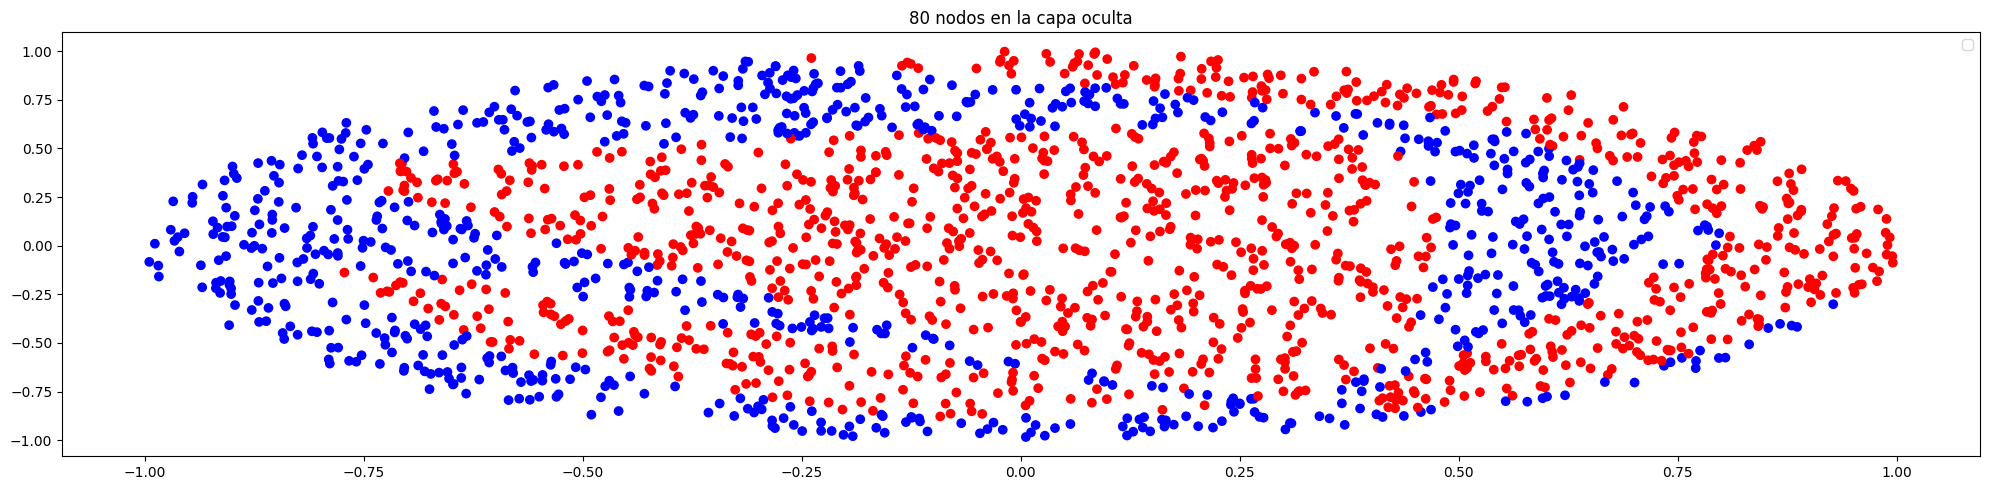

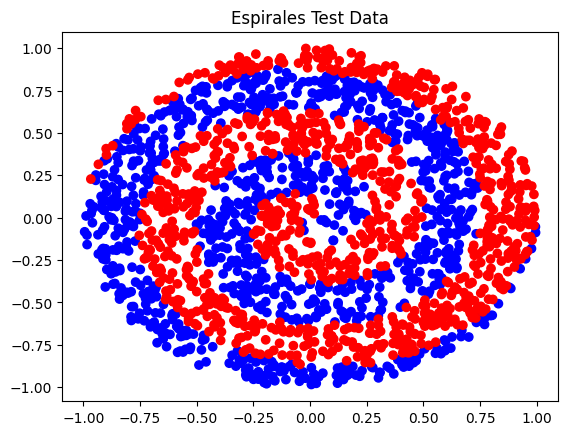

In [14]:
def plotEspiral(df):
    N2s = df.keys()
    fig, ax = plt.subplots(1, len(N2s), figsize=(20, 5))
    N2=N2s[0]
    #for N2, ax in zip(N2s, axs):
    X = df[N2]["input"]
    Y = df[N2]["output"]
    ax.scatter([x[0] for x in X], [x[1] for x in X], c=Y, cmap="bwr")
    ax.set_title("{} nodos en la capa oculta".format(N2))
    ax.legend()
    plt.tight_layout()
    plt.show()

plotEspiral(df)

plt.scatter([x[0] for x in X_test], [x[1] for x in X_test], c=Y_test, cmap="bwr")
plt.title("Espirales Test Data")
plt.show()

## Ejercicio 2

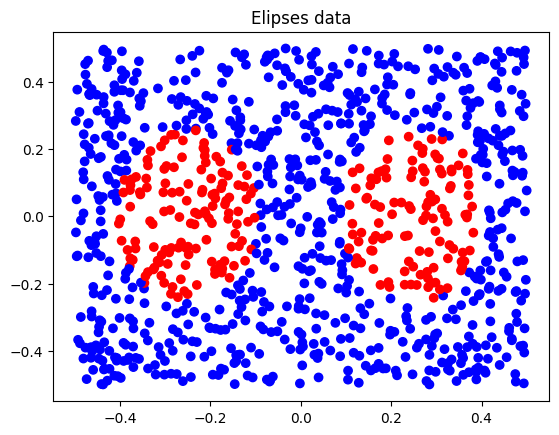

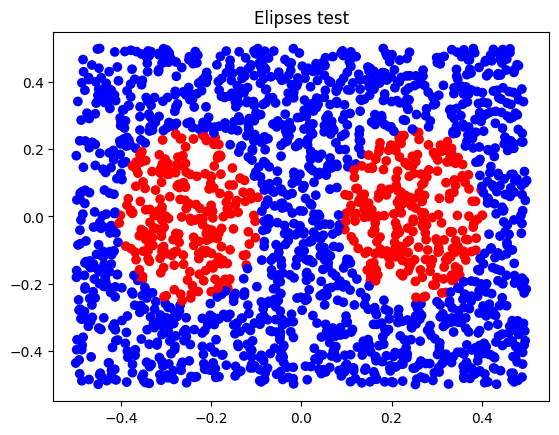

In [7]:
def cargar_csv(path, xcols=2):
    """
    Argumentos:
      path (str): ruta al archivo csv a cargar
      xcols (int): cantidad de columnas que representan las entradas,
        la columna restante representara la clase o dato de salida
    """
    df = pd.read_csv(path, header=None)
    X = df.loc[:, 0:(xcols-1)]
    y = df.loc[:, xcols]
    return X,y

def plot_elipses(data):
    p = data[0]
    c = data[1]

    plt.scatter(p[0], p[1], c=c, cmap="bwr")
    plt.show()

data = cargar_csv("dos_elipses.data")

plt.title("Elipses data")
plot_elipses(data)

test = cargar_csv("dos_elipses.test")
plt.title("Elipses test")
plot_elipses(test)

Entreno los perceptrones

In [ ]:
N2 = 6
super_epocas = 300
sub_epocas = 50

TRAINS = 10

error = []

# Probar diferentes momentos y learning rates

# Elegir un momento
#alfa = 0.5

# Elegir un learning rate
#eta = 0.1

alfas = [0.2]
etas = [0.19]

for alfa in alfas:
    for eta in etas:
        for i in range(TRAINS):
            # Elegir 500 valores del conjunto de data
            X_data,_,Y_data,_ = skl.model_selection.train_test_split(data[0].values.tolist(), data[1].values.tolist(), train_size=500)
            X_train, X_val, Y_train, Y_val = skl.model_selection.train_test_split(X_data,Y_data, train_size=400)

            # Elegir 2000 valores del conjunto de test
            # test ya tiene 2000 elementos
            _,X_test,_,Y_test = skl.model_selection.train_test_split(test[0].values.tolist(), test[1].values.tolist())

            cla = Classifier()

            best_fit, *_ = entrenar_red(cla,X_train,Y_train,X_val,Y_val,X_test,Y_test)

            error.append(1-accuracy_score(Y_test, best_fit.predict(X_test)))

        print("Alfa:", alfa, "Eta:", eta)
        print("Error de test:", np.mean(error)*100)
        print("\n")


c:\Users\Ramiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Ramiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Ramiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Ramiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the opti

Alfa: 0.2 Eta: 0.175
Error de test: 6.180000000000001


